## 3. Komputery zastąpiły rachmistrzów, czy niedługą zastąpią prawników i lekarzy?

Poza nowymi możliwościami w dziedzinie analizy obrazu, uczenie maszynowe można też wykorzystać do rozumienia języka. Dzięki temu możemy ocenić czy opinia jest pozytywna, czy negatywna, poprawić skuteczność wyszukiwarek, a także nauczyć komputer pisania całkiem sensownie brzmiącej prozy (GPT-3). Na tej lekcji przyjżymy się, czy komputer jest w stanie wyszukać w umowach niezgodne z prawem zapisy.

### Dane

Dane pozyskamy z niedawnego konkursu ogłoszonego przez UOKIK. Są one w pliku CSV, gdzie w jednej kolumnie jest kawałek tekstu umowy, a w drugiej etykieta nadana przez ekspertów UOKIKu.

In [128]:
import pandas as pd
from tqdm import tqdm
tqdm.pandas()

In [6]:
data = pd.read_csv('dane treningowe_I etap.csv')

In [8]:
data.head(5)

,text,class
0,Wszelka korespondencja wysyłana przez Pożyczko...,KLAUZULA_ABUZYWNA
1,W przypadku opóźnień Pożyczkobiorcy w spłacie ...,KLAUZULA_ABUZYWNA
2,W przypadku opóźnień Pożyczkobiorcy w spłacie ...,KLAUZULA_ABUZYWNA
3,Pożyczkobiorca zleca firmie Narodowy Fundusz P...,KLAUZULA_ABUZYWNA
4,Od niespłaconej w terminie raty Pożyczkobiorca...,KLAUZULA_ABUZYWNA


Ponieważ cały tekst nie mieści nam się w tabelce zmienimy nieco ustawienia biblioteki Pandas.

In [9]:
pd.set_option('display.max_colwidth', None)

In [11]:
data

,text,class
0,Wszelka korespondencja wysyłana przez Pożyczkodawcę na adres zamieszkania podany w umowie oraz na e-mail zostaje uznana za skutecznie doręczoną. Zmiana adresu e-mail oraz adresu zamieszkania musi być dostarczona do Pożyczkodawcy osobiście,KLAUZULA_ABUZYWNA
1,W przypadku opóźnień Pożyczkobiorcy w spłacie pożyczki Pożyczkodawca ma prawo raz dziennie telefonicznie upomnieć Pożyczkobiorcę do spłaty pożyczki. Za każdy telefon do Pożyczkobiorcy Pożyczkodawca nalicza opłatę w wysokości 100,KLAUZULA_ABUZYWNA
2,W przypadku opóźnień Pożyczkobiorcy w spłacie pożyczki Pożyczkodawca ma prawo wysłać jedno wezwanie dziennie do spłaty pożyczki za pomocą poczty tradycyjnej oraz mailowej na adresy podane w umowie. Za każde wezwanie Pożyczkodawca,KLAUZULA_ABUZYWNA
3,Pożyczkobiorca zleca firmie Narodowy Fundusz Pożyczkowy Sp. z o.o. poręczenie swojej pożyczki i zobowiązuje się zapłacić na rzecz Pożyczkodawcy kwotę 1000 zł (słownie: jeden tysiąc złotych) miesięcznie za każdy miesiąc trwania,KLAUZULA_ABUZYWNA
4,Od niespłaconej w terminie raty Pożyczkobiorca zapłaci Pożyczkodawcy opłaty karne w wysokości 200 złotych w stosunku dziennym,KLAUZULA_ABUZYWNA
...,...,...
4279,CESJA PRAW Z UBEZPIECZENIA NIERUCHOMOŚCI,BEZPIECZNE_POSTANOWIENIE_UMOWNE
4280,Przyznanie i prolongowanie Kredytów na zakup pojazdów Zgodnie z warunkami wynikającymi z umowy,BEZPIECZNE_POSTANOWIENIE_UMOWNE
4281,"Dotyczy to również niniejszych Warunków Imprez Turystycznych, stanowiących integralną część umowy o udział w imprezie turystycznej.",BEZPIECZNE_POSTANOWIENIE_UMOWNE
4282,"Suma ubezpieczenia w kolejnych ubezpieczeniach powinna być równa wartości nieruchomości na moment przedłużenia ubezpieczenia, z zastrzeżeniem ust.",BEZPIECZNE_POSTANOWIENIE_UMOWNE


Nastepnie możemy zrobić szybką analizę tych danych i przerobić je na wygodniejszą postać:

In [15]:
data['class'].unique()

array(['KLAUZULA_ABUZYWNA', 'BEZPIECZNE_POSTANOWIENIE_UMOWNE'],
      dtype=object)

<AxesSubplot:>

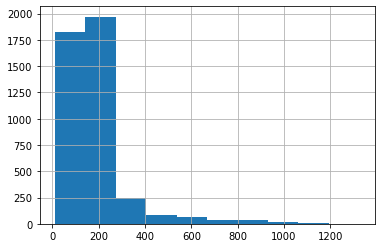

In [19]:
data['text'].str.len().hist()

In [21]:
data['abusive'] = data['class'] == 'KLAUZULA_ABUZYWNA'

In [22]:
del data['class']

In [23]:
data

,text,abusive
0,Wszelka korespondencja wysyłana przez Pożyczkodawcę na adres zamieszkania podany w umowie oraz na e-mail zostaje uznana za skutecznie doręczoną. Zmiana adresu e-mail oraz adresu zamieszkania musi być dostarczona do Pożyczkodawcy osobiście,True
1,W przypadku opóźnień Pożyczkobiorcy w spłacie pożyczki Pożyczkodawca ma prawo raz dziennie telefonicznie upomnieć Pożyczkobiorcę do spłaty pożyczki. Za każdy telefon do Pożyczkobiorcy Pożyczkodawca nalicza opłatę w wysokości 100,True
2,W przypadku opóźnień Pożyczkobiorcy w spłacie pożyczki Pożyczkodawca ma prawo wysłać jedno wezwanie dziennie do spłaty pożyczki za pomocą poczty tradycyjnej oraz mailowej na adresy podane w umowie. Za każde wezwanie Pożyczkodawca,True
3,Pożyczkobiorca zleca firmie Narodowy Fundusz Pożyczkowy Sp. z o.o. poręczenie swojej pożyczki i zobowiązuje się zapłacić na rzecz Pożyczkodawcy kwotę 1000 zł (słownie: jeden tysiąc złotych) miesięcznie za każdy miesiąc trwania,True
4,Od niespłaconej w terminie raty Pożyczkobiorca zapłaci Pożyczkodawcy opłaty karne w wysokości 200 złotych w stosunku dziennym,True
...,...,...
4279,CESJA PRAW Z UBEZPIECZENIA NIERUCHOMOŚCI,False
4280,Przyznanie i prolongowanie Kredytów na zakup pojazdów Zgodnie z warunkami wynikającymi z umowy,False
4281,"Dotyczy to również niniejszych Warunków Imprez Turystycznych, stanowiących integralną część umowy o udział w imprezie turystycznej.",False
4282,"Suma ubezpieczenia w kolejnych ubezpieczeniach powinna być równa wartości nieruchomości na moment przedłużenia ubezpieczenia, z zastrzeżeniem ust.",False


### Tokenizacja i word embeddings

Żeby dowolny tekst mógł zostać przeanalizowany przez algorytm uczenia maszynowego, musimy tekst zamienić na liczby. Oczywiście komputer już to robi (każda litera jest kodowana przez jedną liczbę), ale jak możemy się domysleć, taki sposób kodowania nie ułatwi nam dalszej analizy. Dużo lepiej jest podzielić tekst na słowa i każde słowo zamianić na zestaw liczb, które koduje jego znaczenie.

Skorzystamy z biblioteki Spacy, która zawiera wiele algorytmów wspierających przetwarzanie tekstu.

In [28]:
!conda update --yes spacy

Solving environment: done

## Package Plan ##

  environment location: /home/user/miniconda3/envs/fastai

  added / updated specs:
    - spacy


The following packages will be downloaded:

    package                    |            build
    ---------------------------|-----------------
    aiohttp-3.7.4.post0        |   py38h7f8727e_2         553 KB
    boto3-1.18.21              |     pyhd3eb1b0_0          70 KB
    botocore-1.21.41           |     pyhd3eb1b0_1         3.9 MB
    ca-certificates-2021.10.26 |       h06a4308_2         115 KB
    catalogue-2.0.4            |   py38h06a4308_0          34 KB
    certifi-2021.10.8          |   py38h06a4308_0         151 KB
    click-7.1.2                |     pyhd3eb1b0_0          64 KB
    cryptography-35.0.0        |   py38hd23ed53_0         1.3 MB
    decorator-5.1.0            |     pyhd3eb1b0_0          14 KB
    fastprogress-1.0.0         |     pyhb85f177_0          16 KB
    ffmpeg-4.2.2               |       h20bf706_0        59.6

Po zainstalowaniu Spacy musimy jeszcze pobrać bazę danych mapowań ze słów na wektory liczb dla odpowiedniego języka (w tym wypadku dla polskiego):

In [30]:
!python -m spacy download pl_core_news_lg

     |████████████████████████████████| 612.6 MB 18 kB/s /s eta 0:00:01   |███▊                            | 70.3 MB 78.4 MB/s eta 0:00:07     |█████████████████████████▌      | 487.6 MB 103.1 MB/s eta 0:00:02
✔ Download and installation successful
You can now load the package via spacy.load('pl_core_news_lg')


In [29]:
import spacy

In [32]:
wordmodel = spacy.load('pl_core_news_lg')

In [36]:
tokens = wordmodel(data['text'][0])

Spacy potrafi podzielić nasz tekst na zdania, słowa oraz dla każdego słowa zwrócić nam wektor liczb (jego embedding).

In [41]:
list(tokens.sents)

[Wszelka korespondencja wysyłana przez Pożyczkodawcę na adres zamieszkania podany w umowie oraz na e-mail zostaje uznana za skutecznie doręczoną.,
 Zmiana adresu e-mail oraz adresu zamieszkania musi być dostarczona do Pożyczkodawcy osobiście]

In [64]:
[str(w) for w in tokens]

['Wszelka',
 'korespondencja',
 'wysyłana',
 'przez',
 'Pożyczkodawcę',
 'na',
 'adres',
 'zamieszkania',
 'podany',
 'w',
 'umowie',
 'oraz',
 'na',
 'e',
 '-',
 'mail',
 'zostaje',
 'uznana',
 'za',
 'skutecznie',
 'doręczoną',
 '.',
 'Zmiana',
 'adresu',
 'e',
 '-',
 'mail',
 'oraz',
 'adresu',
 'zamieszkania',
 'musi',
 'być',
 'dostarczona',
 'do',
 'Pożyczkodawcy',
 'osobiście']

In [66]:
embeddings = [w.vector for w in tokens]
embeddings

[array([ 3.1589e-01, -1.2723e+00,  1.0327e-01,  1.8065e+00, -1.7683e+00,
        -2.2052e-01, -1.9266e-01, -4.2429e-01, -6.8029e-01, -8.6304e-01,
         1.1663e+00,  4.4289e-01, -5.0085e-01, -2.9547e-01, -6.5912e-01,
        -1.0072e+00,  1.1787e+00,  3.0847e-01,  2.4791e+00,  2.5733e-01,
         1.8775e+00, -1.0344e+00, -5.2738e-01,  2.9773e+00,  4.8981e-01,
         1.3281e+00, -1.6842e+00,  2.5227e-02,  1.2075e-01,  3.1435e+00,
        -1.6912e+00,  2.1974e+00,  1.9589e-01,  1.1488e+00,  2.5185e+00,
        -1.6602e+00,  3.3139e-01,  1.5322e+00, -2.2332e+00,  1.7582e+00,
        -3.4177e-01,  2.0942e+00, -2.4737e-01,  2.0652e+00, -2.5391e+00,
         1.0811e+00,  1.6885e-01,  2.0243e+00,  1.5604e+00,  5.0932e-01,
        -1.5101e+00,  9.7021e-01,  7.4766e-01,  7.5510e-01,  1.4989e+00,
         2.8958e+00, -5.4559e-01, -8.0583e-02,  3.4331e-01,  7.1987e-03,
         7.2518e-01, -4.9437e-01, -2.3939e+00, -2.0347e+00, -2.7074e-01,
         1.5092e+00, -1.1762e+00, -6.1776e-01,  5.4

In [119]:
np.stack(embeddings).shape

(36, 300)

In [70]:
import numpy as np

Możemy łatwo wyznaczyć takie wektory dla każdej z naszych klauzul, ale niestety mają one różną długość, wiec dostaniemy tablice z bardzo różnych wymiarach i ciężko będzie je porównać. Żeby każdej klauzuli przypisać taką samą ilość liczb możemy spróbować uśrednić każdy element wektora dla wszystkich słów, co da nam łącznie 300 liczb dla całego fragmentu tekstu.

In [124]:
avg_embedding = np.stack(embeddings).mean(axis=0)
avg_embedding

array([ 0.64812213, -0.441166  ,  0.13843998,  0.3660959 , -0.2543102 ,
       -0.13694528, -0.03735112,  1.9366267 , -0.11265544,  0.04841502,
       -1.017733  ,  0.02551251, -2.1857836 ,  0.08883928,  0.69434035,
       -0.72510505,  1.9207761 , -0.6462213 ,  0.18240759, -2.418148  ,
        1.3606687 , -1.1156992 ,  0.11108167,  1.5944567 , -0.05237295,
        0.52012634, -0.42281443, -0.13511944,  0.5361664 ,  0.35827357,
       -0.6088505 ,  0.5384489 , -0.82927585, -0.79123443,  1.0089669 ,
       -0.6931057 , -0.26932633, -0.49852937, -0.475733  ,  1.899744  ,
        0.592868  ,  0.20151633, -1.3291535 ,  1.2554128 , -1.833101  ,
        1.5866771 , -1.0815372 ,  0.75808495, -0.63682866,  0.8930377 ,
       -1.1728592 , -0.46065044, -1.1942495 , -1.0922506 ,  0.7841247 ,
        1.3408952 , -1.479178  ,  0.5573085 , -0.16548252, -0.8219705 ,
        0.29370955,  0.04228573, -0.7379811 , -0.03199125, -0.40886465,
       -0.8443478 , -0.50970143,  0.16359277,  0.02972414,  0.27

In [125]:
avg_embedding.shape

(300,)

Przeanalizowaliśmy wszystkie etapy, więc możemy teraz napisać funkcję, która zamieni dowolny tekst na wektor 300 liczb, które będziemy mogli przeanalizować algorytmem uczenia maszynowego.

In [130]:
def calc_mean_embedding(text):
    tokens = wordmodel(text)
    embeddings = [w.vector for w in tokens]
    return np.stack(embeddings).mean(axis=0)

In [131]:
calc_mean_embedding(data['text'][0])

array([ 0.64812213, -0.441166  ,  0.13843998,  0.3660959 , -0.2543102 ,
       -0.13694528, -0.03735112,  1.9366267 , -0.11265544,  0.04841502,
       -1.017733  ,  0.02551251, -2.1857836 ,  0.08883928,  0.69434035,
       -0.72510505,  1.9207761 , -0.6462213 ,  0.18240759, -2.418148  ,
        1.3606687 , -1.1156992 ,  0.11108167,  1.5944567 , -0.05237295,
        0.52012634, -0.42281443, -0.13511944,  0.5361664 ,  0.35827357,
       -0.6088505 ,  0.5384489 , -0.82927585, -0.79123443,  1.0089669 ,
       -0.6931057 , -0.26932633, -0.49852937, -0.475733  ,  1.899744  ,
        0.592868  ,  0.20151633, -1.3291535 ,  1.2554128 , -1.833101  ,
        1.5866771 , -1.0815372 ,  0.75808495, -0.63682866,  0.8930377 ,
       -1.1728592 , -0.46065044, -1.1942495 , -1.0922506 ,  0.7841247 ,
        1.3408952 , -1.479178  ,  0.5573085 , -0.16548252, -0.8219705 ,
        0.29370955,  0.04228573, -0.7379811 , -0.03199125, -0.40886465,
       -0.8443478 , -0.50970143,  0.16359277,  0.02972414,  0.27

Następnie możemy przetworzyć wszystkie nasze klauzule:

In [132]:
data['mean_embedd'] = data['text'].progress_map(calc_mean_embedding)

100%|██████████| 4284/4284 [00:50<00:00, 84.25it/s] 


### Analiza wielowymiarowych wektorów

Ciężko jest nam wyobrazić sobie i analizować wektory, które mają więcej niż trzy wymiary. Na szczęście są algorytmy, które mogą nam w tym pomóc. PCA i t-SNE pozwalają zredukować ilość wymiarów wektora, starając się jak najbardziej zachować jego odróżnialność od pozostałych wektorów w zbiorze. Dzięki temu możemy zrzutować każde z naszych zdań na płaszczyznę i narysować wykres pokazujący je jako kropki (kolor zależy od tego czy są abuzywne, czy nie).

In [135]:
from sklearn.decomposition import PCA
from sklearn.manifold import TSNE

emb_50 = PCA(n_components=50).fit_transform(np.stack(data['mean_embedd']))
emb_2 = TSNE(n_components = 2, perplexity = 50, init='pca', learning_rate='auto').fit_transform(emb_50)

/home/user/miniconda3/envs/fastai/lib/python3.8/site-packages/sklearn/manifold/_t_sne.py:982: FutureWarning: The PCA initialization in TSNE will change to have the standard deviation of PC1 equal to 1e-4 in 1.2. This will ensure better convergence.
  warnings.warn(


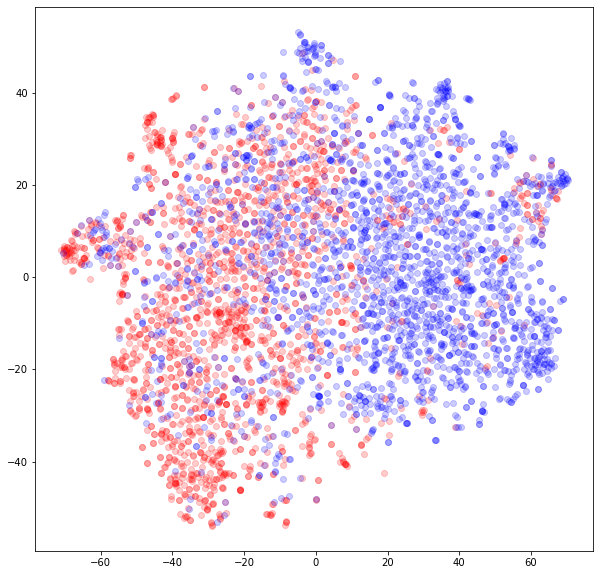

In [137]:
import pylab as plt

plt.figure(figsize=(10,10))
plt.scatter(emb_2[:,0][data['abusive']],emb_2[:,1][data['abusive']], 
            color = 'r', alpha = 0.2, label = 'bad')
plt.scatter(emb_2[:,0][~data['abusive']],emb_2[:,1][~data['abusive']], 
            color = 'b', alpha = 0.2, label = 'good')

Analiza tego wykresu sugeruje, że nasze wektory pozwolą nam, przynajmniej częsciwo, oddzielić bezpieczne zapisy od abuzywnych. Ponieważ PCA i t-SNE są przekształceniami, które tracą część informacji, więc skorzystamy z wektorów pełnej długości (300 elementowych). Do stworzenia klasyfikatora wykorzystamy metodę Random Forrest.

In [162]:
from sklearn.ensemble import RandomForestClassifier

np.random.seed(42)
train_mask = np.random.random(len(data)) > .1

random_forest = RandomForestClassifier(n_estimators = 100, max_depth = None, oob_score=True, max_features = 'sqrt')
random_forest.fit(np.stack(data['mean_embedd'])[train_mask], data['abusive'][train_mask])

RandomForestClassifier(max_features='sqrt', oob_score=True)

Tym razem nie mamy podziału na zbiór treningowy i walidacyjny, ale zastosujemy pewien trik – Random Forrest uczy wiele klasyfikatorów, każdy z nich na losowym podzbiorze danych wejsciowych. Ponieważ żaden z klasyfikatorów nie widzi całego zbioru, więc możemy sprawiedliwie ocenić jego skuteczność sprawdzając go na tych próbkach, których nie widział w procesie uczenia. Metoda ta nazywa się to out-of-bag (OOB) score.

In [163]:
random_forest.oob_score_

0.8268025078369906

82% skuteczności, całkiem nieźle! Zerknijmy na wyniki:

In [164]:
data['mean_abusive_prob'] = [i[1] for i in random_forest.predict_proba(np.stack(data['mean_embedd']))]

In [165]:
data['mean_abusive_pred'] = data['mean_abusive_prob'] > 0.5

In [166]:
data[['text', 'abusive', 'mean_abusive_prob']]

,text,abusive,mean_abusive_prob
0,Wszelka korespondencja wysyłana przez Pożyczkodawcę na adres zamieszkania podany w umowie oraz na e-mail zostaje uznana za skutecznie doręczoną. Zmiana adresu e-mail oraz adresu zamieszkania musi być dostarczona do Pożyczkodawcy osobiście,True,0.86
1,W przypadku opóźnień Pożyczkobiorcy w spłacie pożyczki Pożyczkodawca ma prawo raz dziennie telefonicznie upomnieć Pożyczkobiorcę do spłaty pożyczki. Za każdy telefon do Pożyczkobiorcy Pożyczkodawca nalicza opłatę w wysokości 100,True,0.78
2,W przypadku opóźnień Pożyczkobiorcy w spłacie pożyczki Pożyczkodawca ma prawo wysłać jedno wezwanie dziennie do spłaty pożyczki za pomocą poczty tradycyjnej oraz mailowej na adresy podane w umowie. Za każde wezwanie Pożyczkodawca,True,0.88
3,Pożyczkobiorca zleca firmie Narodowy Fundusz Pożyczkowy Sp. z o.o. poręczenie swojej pożyczki i zobowiązuje się zapłacić na rzecz Pożyczkodawcy kwotę 1000 zł (słownie: jeden tysiąc złotych) miesięcznie za każdy miesiąc trwania,True,0.77
4,Od niespłaconej w terminie raty Pożyczkobiorca zapłaci Pożyczkodawcy opłaty karne w wysokości 200 złotych w stosunku dziennym,True,0.82
...,...,...,...
4279,CESJA PRAW Z UBEZPIECZENIA NIERUCHOMOŚCI,False,0.16
4280,Przyznanie i prolongowanie Kredytów na zakup pojazdów Zgodnie z warunkami wynikającymi z umowy,False,0.13
4281,"Dotyczy to również niniejszych Warunków Imprez Turystycznych, stanowiących integralną część umowy o udział w imprezie turystycznej.",False,0.12
4282,"Suma ubezpieczenia w kolejnych ubezpieczeniach powinna być równa wartości nieruchomości na moment przedłużenia ubezpieczenia, z zastrzeżeniem ust.",False,0.26


Wygląda na to, że nasz model przypisuje wyoskie prawdopodobnieństwa klauzulom abuzywnych, a niskie – bezpiecznym. Zobaczmy jeszcze kilka pomyłek:

In [167]:
data[['text', 'abusive', 'mean_abusive_pred']]

,text,abusive,mean_abusive_pred
0,Wszelka korespondencja wysyłana przez Pożyczkodawcę na adres zamieszkania podany w umowie oraz na e-mail zostaje uznana za skutecznie doręczoną. Zmiana adresu e-mail oraz adresu zamieszkania musi być dostarczona do Pożyczkodawcy osobiście,True,True
1,W przypadku opóźnień Pożyczkobiorcy w spłacie pożyczki Pożyczkodawca ma prawo raz dziennie telefonicznie upomnieć Pożyczkobiorcę do spłaty pożyczki. Za każdy telefon do Pożyczkobiorcy Pożyczkodawca nalicza opłatę w wysokości 100,True,True
2,W przypadku opóźnień Pożyczkobiorcy w spłacie pożyczki Pożyczkodawca ma prawo wysłać jedno wezwanie dziennie do spłaty pożyczki za pomocą poczty tradycyjnej oraz mailowej na adresy podane w umowie. Za każde wezwanie Pożyczkodawca,True,True
3,Pożyczkobiorca zleca firmie Narodowy Fundusz Pożyczkowy Sp. z o.o. poręczenie swojej pożyczki i zobowiązuje się zapłacić na rzecz Pożyczkodawcy kwotę 1000 zł (słownie: jeden tysiąc złotych) miesięcznie za każdy miesiąc trwania,True,True
4,Od niespłaconej w terminie raty Pożyczkobiorca zapłaci Pożyczkodawcy opłaty karne w wysokości 200 złotych w stosunku dziennym,True,True
...,...,...,...
4279,CESJA PRAW Z UBEZPIECZENIA NIERUCHOMOŚCI,False,False
4280,Przyznanie i prolongowanie Kredytów na zakup pojazdów Zgodnie z warunkami wynikającymi z umowy,False,False
4281,"Dotyczy to również niniejszych Warunków Imprez Turystycznych, stanowiących integralną część umowy o udział w imprezie turystycznej.",False,False
4282,"Suma ubezpieczenia w kolejnych ubezpieczeniach powinna być równa wartości nieruchomości na moment przedłużenia ubezpieczenia, z zastrzeżeniem ust.",False,False


In [170]:
val_data = data[~train_mask]

In [174]:
val_data[['text', 'abusive', 'mean_abusive_prob']][val_data['mean_abusive_pred'] != val_data['abusive']].sort_values('mean_abusive_prob')

,text,abusive,mean_abusive_prob
369,"Zwrot pieniędzy następuje po odesłaniu przez Klienta podpisanej kopii faktury/noty korygującej na adres sprzedawcy: STIMO, ul. Sikorskiego 11a; 38-400 Krosno.",True,0.04
1319,"Strony mają obowiązek rozwiązywać wszelkie spory w sposób polubowny. Procedura oficjalnej skargi: a) Rodzic niezwłocznie zawiadamia Sekretariat pisemnie lub e-mail’em o zaistniałym problemie; Przedszkole niezwłocznie zawiadamia Rodzica pisemnie lub e-mail’em o zaistniałym problemie, b) Przedszkole w terminie 7 dni od otrzymania/składania zawiadomienia organizuje spotkanie z Rodzicem, c) Na spotkaniu, Rodzic i Przedszkole przedstawiają i uzgadniają plan działania w celu rozwiązania problemu, d) Niezwłocznie po spotkaniu ustalony plan podlega realizacji przez każdą z stron, e) Rodzic i Przedszkole informują siebie wzajemnie na bieżąco o postępach",True,0.12
486,"Bank może w trakcie obowiązywania Umowy: 1) zwiększyć wysokość przyznanego Limitu, o ile zdolność kredytowa Posiadacza/y rachunku będzie pozwalała na spłatę zwiększonej wysokości Limitu, a Posiadacz/e rachunku rzetelnie wywiązywać się",True,0.13
1116,"W przypadku braku spłaty należności Pożyczkodawcy z tytułu udzielonej Pożyczkobiorcy pożyczki, w terminie określonym w niniejszej Umowie Pożyczki, Pożyczkodawca ma prawo do wystąpienia na drogę windykacyjną. Wpłaty dokonane przez Pożyczkobiorcę zaliczone będą na spłatę należności z tytułu Umowy Pożyczki, bez względu na ewentualne późniejsze dyspozycje Pożyczkobiorcy, według następującej kolejności: a) koszty windykacji, w tym koszty upomnień i wezwań związane z dochodzeniem roszczenia; b) prowizje i opłaty oraz koszty płatne zgodnie Umową Pożyczki; c) odsetki od kapitału przeterminowanego; d) wymagalne odsetki za okresy obrachunkowe; e) kapitał przeterminowany; f) odsetki bieżące; g) kapitał niewymagalny.",True,0.14
83,"Zgodnie z Ustawą z dn. 2.03.2000 r. (Dz.U. z 2000 r. Nr 22, poz. 271 z późniejszymi zmianami) O ochronie praw konsumentów - Klient, który zakupił towar poza lokalem oferującego go przedsiębiorstwa ma prawo odstąpić od umowy kupna w terminie",True,0.15
...,...,...,...
2448,•Status sponsora Imprezy przyznaje wyłącznie Organizator. Organizator nie ponosi odpowiedzialności za skutki działania Siły Wyższej.,False,0.79
1997,"Kupujący może złożyć reklamacje wraz z reklamowanym Towarem oraz fakturą dokumentującą dokonanie zakupu na adres: Fabryka Graczy Sp. z o.o. ul. Konstantynowska 34, 94-303. W celu usprawnienia procesu reklamacji Klient może skorzystać z formularza reklamacyjnego dostępnego na stronie w dziale Regulamin Serwisu. Jeśli Kupujący jest konsumentem, brak faktury, materiału zdjęciowego oraz protokołu nie może stanowić wyłącznej podstawy odmowy uwzględnienia reklamacji, jeśli okoliczności zakupu Towaru mogą być ustalone na podstawie innych dowodów .",False,0.80
3743,"a)kosztów naprawy, jeśli uszkodzenia dają się usunąć, b)kary umownej za wymianę Sprzętu zgodnie z Cennikiem, jeśli Sprzęt został utracony łub jeżeli uszkodzenia nie dają się usunąć.",False,0.85
2212,Sądem właściwym dla rozpoznawania sporów wynikających z umowy jest sąd właściwy dla miejsca zamieszkania pozwanego,False,0.89


In [179]:
len(val_data)

456

In [180]:
1 - 91 / len(val_data)

0.8004385964912281

91 błędów na 456 klauzul. Dokładność na poziomie 80%. Trochę za mało, żeby zastąpić prawników i sędziów komputerami, ale w kolejnym kursie sprawdzimy jak możemy tę dokładność mocno poprawić.